# BlueStock Mutual Fund Capstone

## Exploratory Data Analysis (EDA)

**Intern:** Muskan Agrawal

This notebook contains exploratory data analysis of the BlueStock Mutual Fund dataset.

The objective is to analyze:

- NAV Trends
- AUM Growth
- SIP Inflows
- Category-wise Investments
- Investor Demographics
- Geographic Distribution
- Portfolio Holdings
- Fund Performance

# BlueStock Mutual Fund Capstone Project

## Day 3 - Exploratory Data Analysis (EDA)

**Objective**

Perform exploratory data analysis on the cleaned mutual fund datasets to identify trends, investor behaviour, fund performance, SIP growth, AUM growth, portfolio allocation, and overall industry insights using Python visualizations.

---

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [7]:
project_path = Path.cwd().parent

raw_path = project_path / "data" / "raw"
processed_path = project_path / "data" / "processed"

print("Project Path:", project_path)
print("Raw Path:", raw_path)
print("Processed Path:", processed_path)

Project Path: c:\Users\agraw\OneDrive\Desktop\Bluestock_MF_Capstone
Raw Path: c:\Users\agraw\OneDrive\Desktop\Bluestock_MF_Capstone\data\raw
Processed Path: c:\Users\agraw\OneDrive\Desktop\Bluestock_MF_Capstone\data\processed


In [1]:
print("Hello Muskan! You did it!!")

Hello Muskan! You did it!!


In [8]:
fund_master = pd.read_csv(processed_path / "01_fund_master_cleaned.csv")
nav_history = pd.read_csv(processed_path / "02_nav_history_cleaned.csv")
aum = pd.read_csv(processed_path / "03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(processed_path / "04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(processed_path / "05_category_inflows_cleaned.csv")
folio = pd.read_csv(processed_path / "06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(processed_path / "07_scheme_performance_cleaned.csv")
transactions = pd.read_csv(processed_path / "08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv(processed_path / "09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [9]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [10]:
# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort the data
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Check the first few rows
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [11]:
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig.update_layout(
    height=700,
    template="plotly_white"
)

fig.show()

### Observation 1: Daily NAV Trend

The interactive line chart shows the daily NAV movement of all mutual fund schemes from 2022 to 2026. It helps identify long-term growth trends, market fluctuations, and comparative performance across schemes. The chart can also be used to observe periods of market expansion and correction.

In [12]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [13]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [14]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Check the data
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


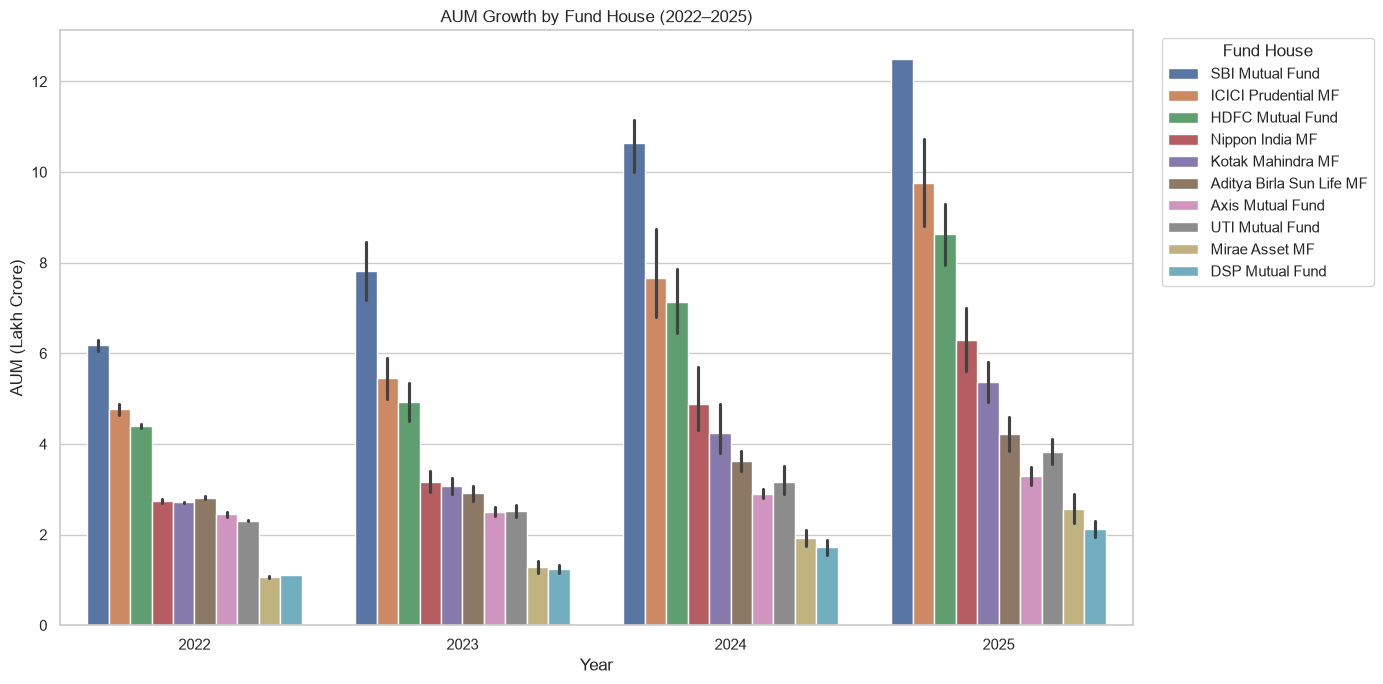

In [15]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Fund House"
)

plt.tight_layout()
plt.show()

### Observation 2: AUM Growth by Fund House

The grouped bar chart compares Assets Under Management (AUM) across major fund houses from 2022 to 2025. SBI Mutual Fund emerged as the market leader, crossing **₹12.5 lakh crore AUM in 2025**, significantly ahead of other fund houses. The chart highlights the steady growth of India's mutual fund industry over the four-year period.

In [16]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [17]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [18]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Check data
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [19]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

# Highlight the highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'All-Time High: ₹{max_row["sip_inflow_crore"]:,} Cr',
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-50
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

### Observation 3: Monthly SIP Inflow Trend

The monthly SIP inflow showed a strong upward trend from January 2022 to December 2025, reflecting increasing retail investor participation in mutual funds. The highest monthly SIP inflow reached **₹31,002 crore in December 2025**, indicating record investor confidence and consistent growth in systematic investments.

In [20]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [21]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [22]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Format month as YYYY-MM for display
category["month"] = category["month"].dt.strftime("%Y-%m")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


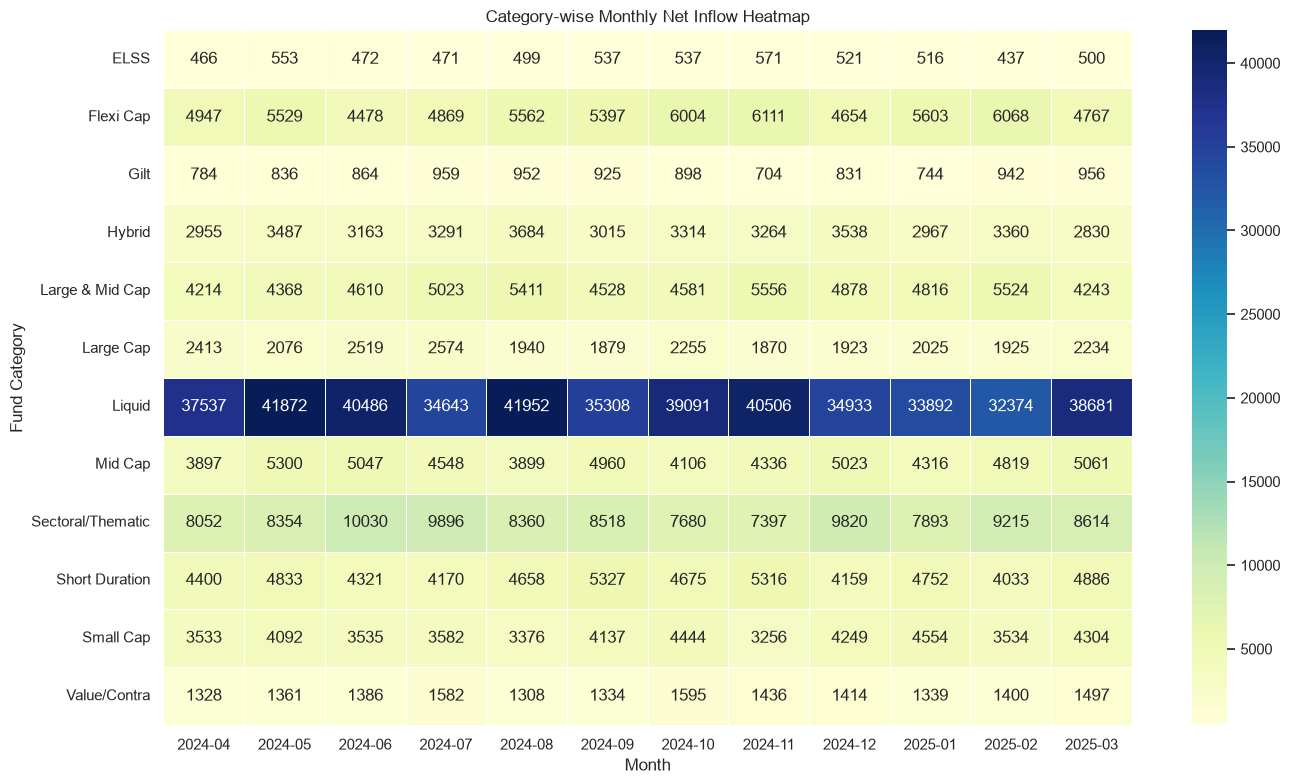

In [23]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

### Observation 4: Category-wise Monthly Net Inflow

The heatmap compares monthly net inflows across different mutual fund categories. Flexi Cap, Mid Cap, and Large & Mid Cap funds consistently attracted higher investor inflows, while some categories experienced comparatively lower inflows. The colour intensity makes it easy to identify periods of strong and weak investment activity across categories.

In [24]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [25]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [26]:
age_counts = transactions["age_group"].value_counts()

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Age Group Distribution"
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.show()

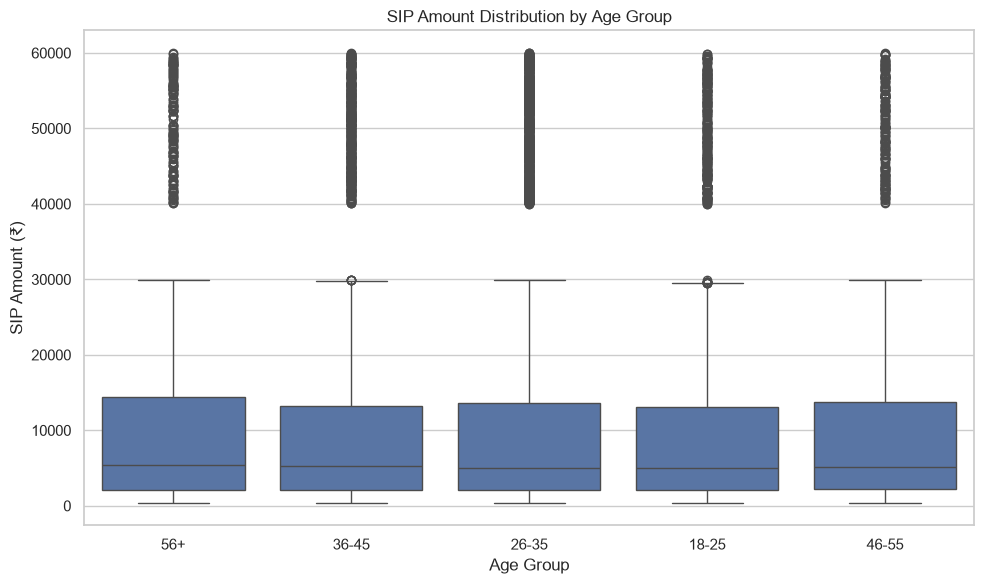

In [27]:
sip_data = transactions[transactions["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()
plt.show()

In [28]:
gender_counts = transactions["gender"].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Gender Distribution of Investors"
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.show()

### Observation 5: Investor Demographics

The investor demographic analysis shows participation across multiple age groups, with the **26–35** and **36–45** age groups contributing a significant share of investors. SIP investments are distributed across all age groups, while the gender distribution indicates healthy participation from both male and female investors.

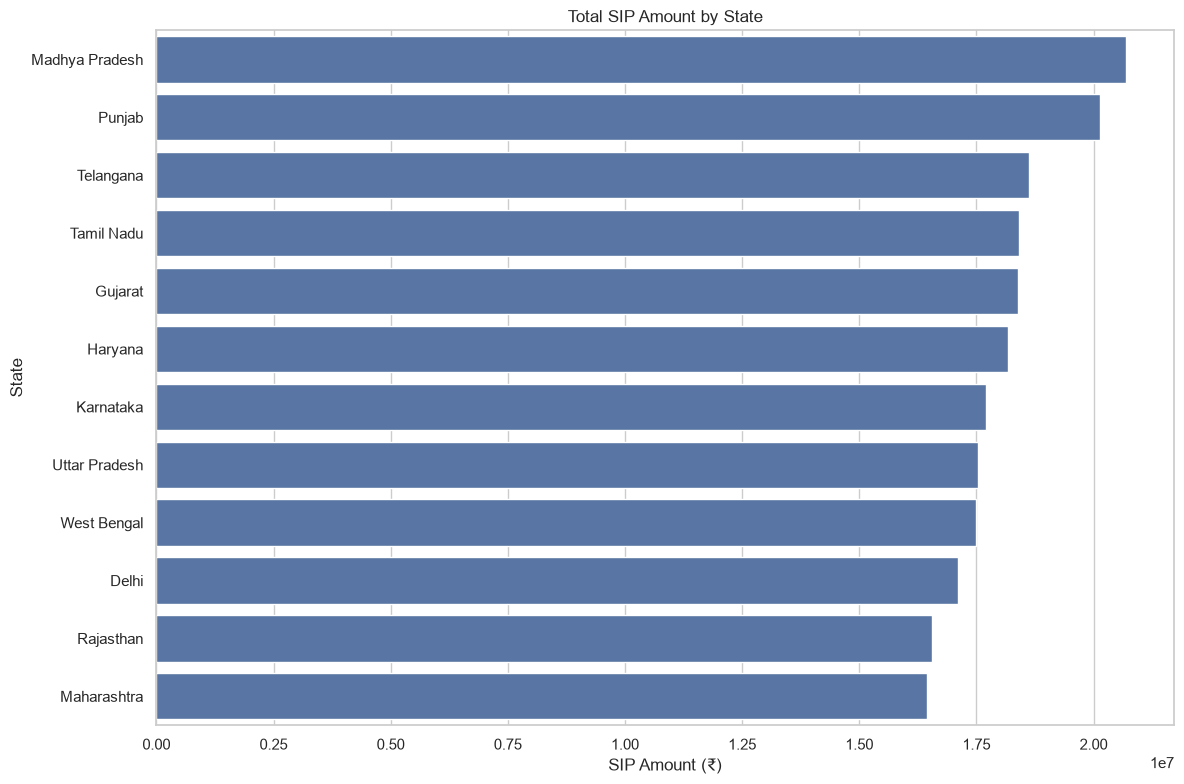

In [29]:
# Total SIP amount by state
state_sip = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [30]:
city_counts = transactions["city_tier"].value_counts()

fig = px.pie(
    values=city_counts.values,
    names=city_counts.index,
    title="Investor Distribution: T30 vs B30 Cities"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Observation 6: Geographic Distribution

The state-wise SIP chart highlights the regions contributing the highest SIP investment amounts, reflecting strong participation from major financial hubs. The T30 vs B30 city distribution indicates that while metropolitan cities dominate investments, participation from B30 cities continues to grow, demonstrating deeper mutual fund penetration across India.

In [31]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [32]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [33]:
# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [34]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

# Mark first point
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True,
    ay=-40
)

# Mark last point
fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True,
    ay=-40
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

### Observation 7: Mutual Fund Folio Growth

The number of mutual fund folios nearly doubled between 2022 and 2025, increasing from **13.26 crore** to approximately **26.12 crore**. This reflects growing retail participation and increased investor awareness in the Indian mutual fund industry.

In [35]:
portfolio.columns
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [36]:
# Aggregate sector weights
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [37]:
fig = px.pie(
    values=sector_weights.values,
    names=sector_weights.index,
    hole=0.45,
    title="Sector Allocation Across Equity Mutual Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Observation 8: Sector Allocation

The sector allocation analysis shows that Banking, IT, Pharma, Utilities, and Diversified sectors account for a significant portion of equity mutual fund portfolios. This indicates that fund managers maintain diversified portfolios while allocating higher weights to sectors with strong long-term growth potential.

In [38]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [39]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [40]:
# Select 10 AMFI codes
selected_funds = nav_history["amfi_code"].unique()[:10]

# Filter NAV history for these funds
corr_data = nav_history[nav_history["amfi_code"].isin(selected_funds)]

# Pivot the data
pivot_nav = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_nav.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [41]:
# Calculate daily returns
daily_returns = pivot_nav.pct_change()

# Correlation matrix
correlation_matrix = daily_returns.corr()

correlation_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


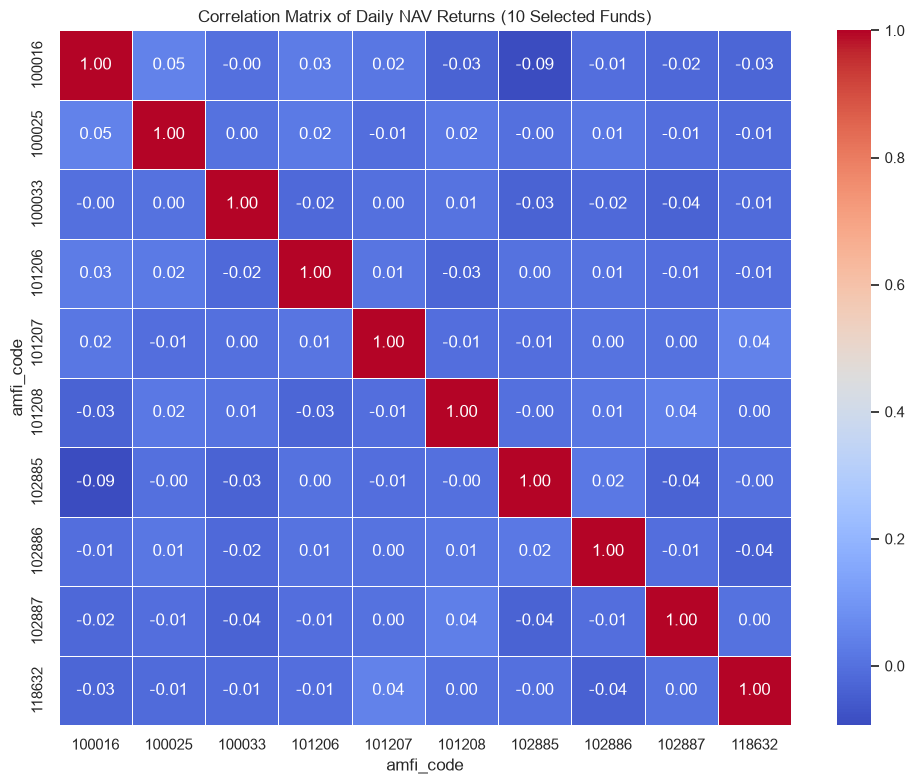

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Selected Funds)")

plt.tight_layout()
plt.show()

### Observation 9: NAV Return Correlation

The correlation matrix shows that most selected mutual funds exhibit strong positive correlations in their daily NAV returns. This indicates that equity-oriented mutual funds generally move together in response to broader market conditions while still maintaining diversification across sectors and fund managers.

In [43]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

In [44]:
fig = px.pie(
    values=sector_weights.values,
    names=sector_weights.index,
    hole=0.45,
    title="Sector Allocation Across Equity Mutual Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Observation 10: Sector Allocation

The sector allocation analysis indicates that Banking, Information Technology, Pharma, Utilities, and Diversified sectors constitute a major share of equity mutual fund portfolios. This reflects a balanced investment strategy focused on long-term growth and diversification.